# Student Project Performance Analytics Dashboard

Assessment-ready end-to-end notebook aligned to Unit 4:
- data ingestion and cleaning
- contribution and team metrics
- bias/fairness checks
- admin-facing insights and exports

## 1) Environment Setup and Dependency Installation

In [32]:
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Python: {sys.version.split()[0]}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Python: 3.12.4
Pandas: 3.0.2
NumPy: 2.4.4


## 2) Project Structure and Reproducibility Configuration

In [33]:
# Work reliably regardless of where the notebook is opened from
cwd = Path.cwd()
if cwd.name == "notebooks":
    PROJECT_ROOT = cwd.parent
else:
    PROJECT_ROOT = cwd

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUT_GRAPHS = PROJECT_ROOT / "outputs" / "graphs"
OUTPUT_REPORTS = PROJECT_ROOT / "outputs" / "reports"

for p in [DATA_RAW, DATA_PROCESSED, OUTPUT_GRAPHS, OUTPUT_REPORTS, PROJECT_ROOT / "scripts", PROJECT_ROOT / "notebooks"]:
    p.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Project root:", PROJECT_ROOT)
print("Raw data dir:", DATA_RAW)

Project root: d:\projects\Sprint3project
Raw data dir: d:\projects\Sprint3project\data\raw


## 3) Data Schema and Metric Definitions

In [34]:
required_columns = {
    "student_info": ["student_id", "student_name", "team_id"],
    "task_logs": ["student_id", "tasks_assigned", "tasks_completed", "avg_task_hours"],
    "git_activity": ["student_id", "commits", "prs_opened", "prs_merged", "code_lines_changed"],
    "peer_reviews": ["student_id", "peer_rating"],
    "attendance": ["student_id", "meetings_attended", "total_meetings"],
    "progress": ["student_id", "week1_progress", "week2_progress", "week3_progress", "week4_progress"],
}

metric_definitions = {
    "contribution_score": "Weighted normalized score: 30% tasks, 20% commits, 15% PR merges, 15% code churn, 10% attendance, 10% peer rating.",
    "team_balance_score": "100 × (1 - coefficient_of_variation of team contribution), clipped to [0,100].",
    "progress_score": "Average of week1..week4 progress percentages.",
}

pd.DataFrame(
    [{"metric": k, "definition": v} for k, v in metric_definitions.items()]
)

,metric,definition
0,contribution_score,"Weighted normalized score: 30% tasks, 20% comm..."
1,team_balance_score,100 × (1 - coefficient_of_variation of team co...
2,progress_score,Average of week1..week4 progress percentages.


## 4) Dataset Ingestion (CSV) and Synthetic Data Generation

In [35]:
main_file = DATA_RAW / "student_project_activity.csv"

if not main_file.exists():
    # Synthetic fallback if CSV is missing
    n_students = 40
    teams = [f"T{i:02d}" for i in range(1, 9)]
    df_main = pd.DataFrame({
        "student_id": [f"S{i:03d}" for i in range(1, n_students + 1)],
        "student_name": [f"Student_{i:03d}" for i in range(1, n_students + 1)],
        "team_id": [teams[(i - 1) // 5] for i in range(1, n_students + 1)],
        "tasks_assigned": np.random.randint(6, 15, n_students),
        "tasks_completed": np.random.randint(3, 14, n_students),
        "avg_task_hours": np.round(np.random.uniform(2.0, 9.5, n_students), 2),
        "commits": np.random.randint(2, 85, n_students),
        "prs_opened": np.random.randint(1, 30, n_students),
        "prs_merged": np.random.randint(0, 28, n_students),
        "code_lines_changed": np.random.randint(80, 4500, n_students),
        "peer_rating": np.round(np.random.uniform(1.5, 5.0, n_students), 2),
        "meetings_attended": np.random.randint(3, 11, n_students),
        "total_meetings": 10,
        "week1_progress": np.random.randint(5, 40, n_students),
        "week2_progress": np.random.randint(20, 65, n_students),
        "week3_progress": np.random.randint(35, 90, n_students),
        "week4_progress": np.random.randint(55, 100, n_students),
    })
    df_main.to_csv(main_file, index=False)
else:
    df_main = pd.read_csv(main_file)

print("Loaded data shape:", df_main.shape)
df_main.head()

Loaded data shape: (40, 17)


,student_id,student_name,team_id,tasks_assigned,tasks_completed,avg_task_hours,commits,prs_opened,prs_merged,code_lines_changed,peer_rating,meetings_attended,total_meetings,week1_progress,week2_progress,week3_progress,week4_progress
0,S001,Aarav,T01,6,4,6.20,18,8,5,109.0,3.22,9.0,10,19,31,57,78
1,S002,Diya,T01,12,9,6.80,31,13,13,471.0,4.34,7.0,10,19,35,50,74
2,S003,Ishan,T01,10,7,4.44,25,12,9,640.0,4.93,9.0,10,16,30,44,63
3,S004,Meera,T01,12,11,4.82,30,12,10,823.0,NaN,8.0,10,14,33,53,69
4,S005,Rohan,T01,8,7,6.09,22,6,4,622.0,3.45,7.0,10,16,29,47,73


In [36]:
# Split into logical source tables and persist (for assessment clarity)
student_info = df_main[["student_id", "student_name", "team_id"]].copy()
task_logs = df_main[["student_id", "tasks_assigned", "tasks_completed", "avg_task_hours"]].copy()
git_activity = df_main[["student_id", "commits", "prs_opened", "prs_merged", "code_lines_changed"]].copy()
peer_reviews = df_main[["student_id", "peer_rating"]].copy()
attendance = df_main[["student_id", "meetings_attended", "total_meetings"]].copy()
progress = df_main[["student_id", "week1_progress", "week2_progress", "week3_progress", "week4_progress"]].copy()

student_info.to_csv(DATA_RAW / "student_info.csv", index=False)
task_logs.to_csv(DATA_RAW / "task_logs.csv", index=False)
git_activity.to_csv(DATA_RAW / "git_activity.csv", index=False)
peer_reviews.to_csv(DATA_RAW / "peer_reviews.csv", index=False)
attendance.to_csv(DATA_RAW / "attendance.csv", index=False)
progress.to_csv(DATA_RAW / "progress.csv", index=False)

print("Raw source tables saved under data/raw")

Raw source tables saved under data/raw


## 5) Data Quality Checks and Validation Rules

In [37]:
for name, cols in required_columns.items():
    missing = [c for c in cols if c not in df_main.columns]
    assert not missing, f"Missing columns in {name}: {missing}"

# Standardize names and remove duplicates
df = df_main.copy()
df.columns = [c.strip().lower() for c in df.columns]
df = df.drop_duplicates(subset=["student_id"]).copy()

# Type enforcement
int_cols = [
    "tasks_assigned", "tasks_completed", "commits", "prs_opened", "prs_merged",
    "code_lines_changed", "meetings_attended", "total_meetings",
    "week1_progress", "week2_progress", "week3_progress", "week4_progress"
]
for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["avg_task_hours"] = pd.to_numeric(df["avg_task_hours"], errors="coerce")
df["peer_rating"] = pd.to_numeric(df["peer_rating"], errors="coerce")

# Missing-value handling
for col in int_cols:
    df[col] = df[col].fillna(df[col].median())
df["avg_task_hours"] = df["avg_task_hours"].fillna(df["avg_task_hours"].median())
df["peer_rating"] = df["peer_rating"].fillna(df["peer_rating"].median())

# Non-negative constraints
for col in ["tasks_assigned", "tasks_completed", "commits", "prs_opened", "prs_merged", "code_lines_changed", "meetings_attended"]:
    df[col] = df[col].clip(lower=0)

df["tasks_completed"] = np.minimum(df["tasks_completed"], df["tasks_assigned"])
df["prs_merged"] = np.minimum(df["prs_merged"], df["prs_opened"])
df["meetings_attended"] = np.minimum(df["meetings_attended"], df["total_meetings"])

print("Cleaned shape:", df.shape)
print("Missing values after cleaning:")
print(df.isna().sum().sum())

Cleaned shape: (40, 17)
Missing values after cleaning:
0


## 6) Data Cleaning and Feature Engineering

In [38]:
df["attendance_ratio"] = (df["meetings_attended"] / df["total_meetings"]).clip(0, 1)
df["task_completion_rate"] = np.where(df["tasks_assigned"] > 0, df["tasks_completed"] / df["tasks_assigned"], 0)
df["commit_intensity"] = df["commits"] / (df["tasks_completed"].replace(0, 1))
df["pr_merge_rate"] = np.where(df["prs_opened"] > 0, df["prs_merged"] / df["prs_opened"], 0)
df["progress_score"] = df[["week1_progress", "week2_progress", "week3_progress", "week4_progress"]].mean(axis=1)
df["completion_lag_proxy"] = (100 - df["week4_progress"]).clip(0, 100)

df[["student_id", "team_id", "attendance_ratio", "task_completion_rate", "commit_intensity", "pr_merge_rate", "progress_score"]].head()

,student_id,team_id,attendance_ratio,task_completion_rate,commit_intensity,pr_merge_rate,progress_score
0,S001,T01,0.9,0.666667,4.500000,0.625000,46.25
1,S002,T01,0.7,0.750000,3.444444,1.000000,44.50
2,S003,T01,0.9,0.700000,3.571429,0.750000,38.25
3,S004,T01,0.8,0.916667,2.727273,0.833333,42.25
4,S005,T01,0.7,0.875000,3.142857,0.666667,41.25


## 7) Student Contribution Score Calculation

In [39]:
def minmax(series: pd.Series) -> pd.Series:
    min_v, max_v = series.min(), series.max()
    if max_v == min_v:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return (series - min_v) / (max_v - min_v)

weights = {
    "task_completion_rate": 0.30,
    "commits": 0.20,
    "prs_merged": 0.15,
    "code_lines_changed": 0.15,
    "attendance_ratio": 0.10,
    "peer_rating": 0.10,
}

for col in ["commits", "prs_merged", "code_lines_changed", "peer_rating"]:
    df[f"norm_{col}"] = minmax(df[col])

df["contribution_score"] = 100 * (
    weights["task_completion_rate"] * df["task_completion_rate"]
    + weights["commits"] * df["norm_commits"]
    + weights["prs_merged"] * df["norm_prs_merged"]
    + weights["code_lines_changed"] * df["norm_code_lines_changed"]
    + weights["attendance_ratio"] * df["attendance_ratio"]
    + weights["peer_rating"] * df["norm_peer_rating"]
)

# Team-relative ranking
df["team_rank"] = df.groupby("team_id")["contribution_score"].rank(ascending=False, method="dense")

df[["student_id", "team_id", "contribution_score", "team_rank"]].sort_values(["team_id", "team_rank"]).head(12)

,student_id,team_id,contribution_score,team_rank
3,S004,T01,76.533660,1.0
1,S002,T01,70.605454,2.0
2,S003,T01,68.227273,3.0
4,S005,T01,58.688175,4.0
0,S001,T01,42.869610,5.0
9,S010,T02,46.056090,1.0
5,S006,T02,44.786556,2.0
7,S008,T02,44.655056,3.0
6,S007,T02,33.963165,4.0
8,S009,T02,32.210563,5.0


## 8) Team Balance, Progress, and Delay Metrics

In [40]:
team_metrics = df.groupby("team_id").agg(
    team_size=("student_id", "count"),
    team_contribution_mean=("contribution_score", "mean"),
    team_contribution_std=("contribution_score", "std"),
    team_progress_mean=("progress_score", "mean"),
    team_completion_rate=("task_completion_rate", "mean"),
    team_delay_indicator=("completion_lag_proxy", "mean"),
).reset_index()

team_metrics["team_contribution_std"] = team_metrics["team_contribution_std"].fillna(0)
team_metrics["cv_contribution"] = np.where(
    team_metrics["team_contribution_mean"] > 0,
    team_metrics["team_contribution_std"] / team_metrics["team_contribution_mean"],
    0,
)
team_metrics["team_balance_score"] = (100 * (1 - team_metrics["cv_contribution"]).clip(0, 1)).round(2)
team_metrics["team_performance_score"] = (
    0.5 * team_metrics["team_contribution_mean"]
    + 0.3 * team_metrics["team_progress_mean"]
    + 0.2 * (team_metrics["team_completion_rate"] * 100)
).round(2)
team_metrics["risk_flag"] = np.where(
    (team_metrics["team_balance_score"] < 70) | (team_metrics["team_delay_indicator"] > 25),
    "At-Risk",
    "Stable",
)

team_metrics.sort_values("team_performance_score", ascending=False)

,team_id,team_size,team_contribution_mean,team_contribution_std,team_progress_mean,team_completion_rate,team_delay_indicator,cv_contribution,team_balance_score,team_performance_score,risk_flag
6,T07,5,61.340700,25.359525,52.25,0.789524,19.6,0.413421,58.66,62.14,At-Risk
5,T06,5,61.720220,19.112554,45.05,0.810794,25.4,0.309664,69.03,60.59,At-Risk
0,T01,5,63.384834,13.147349,42.50,0.781667,28.6,0.207421,79.26,60.08,At-Risk
7,T08,5,56.022626,10.571687,52.65,0.635311,23.8,0.188704,81.13,56.51,Stable
4,T05,5,55.092656,16.869520,48.00,0.684799,26.2,0.306203,69.38,55.64,At-Risk
3,T04,5,49.459197,9.609575,52.60,0.720635,20.4,0.194293,80.57,54.92,Stable
2,T03,5,47.644076,18.874785,46.80,0.746111,25.6,0.396162,60.38,52.78,At-Risk
1,T02,5,40.334286,6.667400,48.80,0.664177,24.8,0.165304,83.47,48.09,Stable


## 9) Peer Review Reliability and Bias Handling

In [41]:
# Compare subjective (peer) vs objective (activity) evidence
df["activity_evidence"] = 100 * (
    0.35 * df["task_completion_rate"]
    + 0.25 * df["norm_commits"]
    + 0.20 * df["norm_prs_merged"]
    + 0.20 * df["attendance_ratio"]
)
df["peer_scaled"] = 100 * df["norm_peer_rating"]
df["disagreement_score"] = (df["peer_scaled"] - df["activity_evidence"]).abs()

df["bias_flag"] = np.where(df["disagreement_score"] > 25, "Potential Bias", "Aligned")

corr = df[["peer_scaled", "activity_evidence"]].corr().iloc[0, 1]
print(f"Correlation (peer vs activity): {corr:.3f}")
df[["student_id", "team_id", "peer_scaled", "activity_evidence", "disagreement_score", "bias_flag"]].head(10)

Correlation (peer vs activity): 0.526


,student_id,team_id,peer_scaled,activity_evidence,disagreement_score,bias_flag
0,S001,T01,39.575972,52.650298,13.074326,Aligned
1,S002,T01,79.151943,73.151786,6.000158,Aligned
2,S003,T01,100.000000,65.000000,35.000000,Potential Bias
3,S004,T01,52.826855,75.918155,23.091300,Aligned
4,S005,T01,47.703180,57.638393,9.935213,Aligned
5,S006,T02,56.183746,44.020833,12.162912,Aligned
6,S007,T02,28.621908,38.084821,9.462913,Aligned
7,S008,T02,43.462898,47.723620,4.260723,Aligned
8,S009,T02,20.141343,40.459821,20.318479,Aligned
9,S010,T02,53.710247,53.151786,0.558462,Aligned


## 10) Exploratory Data Analysis (EDA) and Visual Panels

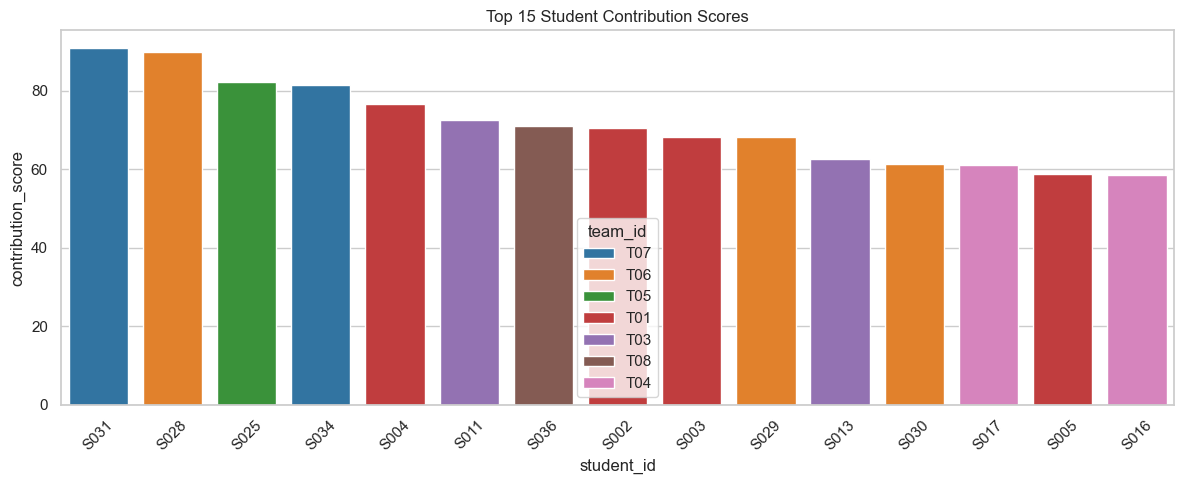

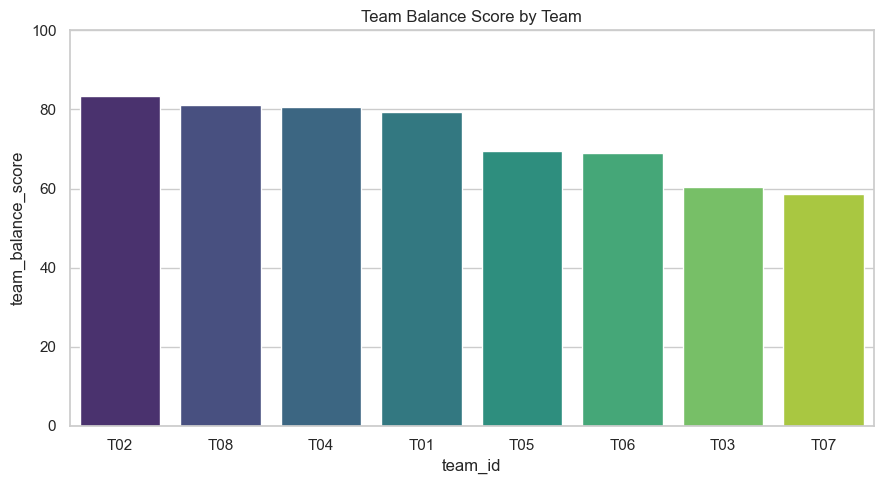

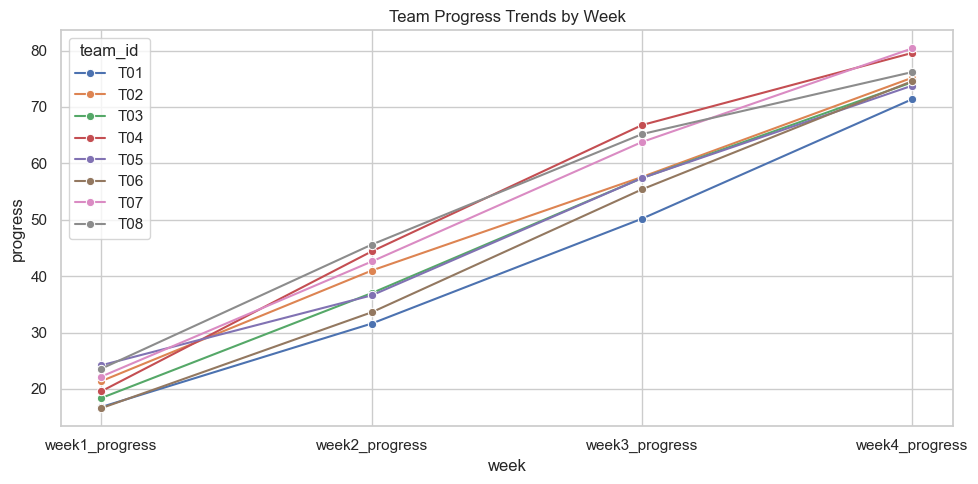

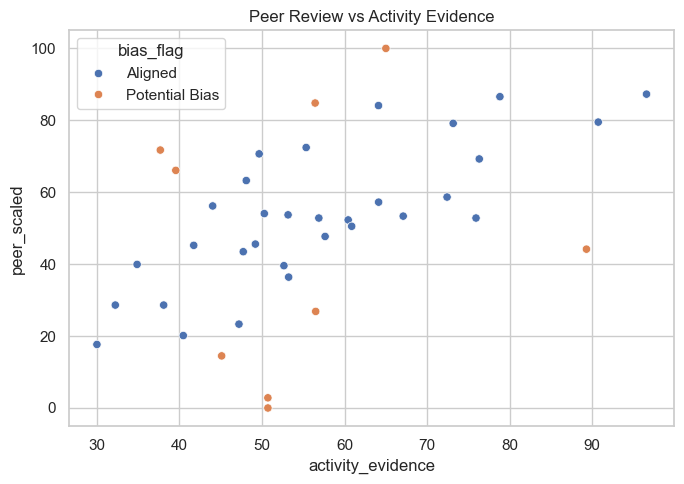

In [42]:
sns.set_theme(style="whitegrid")

# 1) Top student contributions
plt.figure(figsize=(12, 5))
top_students = df.sort_values("contribution_score", ascending=False).head(15)
sns.barplot(data=top_students, x="student_id", y="contribution_score", hue="team_id", palette="tab10")
plt.xticks(rotation=45)
plt.title("Top 15 Student Contribution Scores")
plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / "top_student_contributions.png", dpi=150)
plt.show()

# 2) Team balance scores
plt.figure(figsize=(9, 5))
team_balance_plot = team_metrics.sort_values("team_balance_score", ascending=False)
sns.barplot(
    data=team_balance_plot,
    x="team_id",
    y="team_balance_score",
    hue="team_id",
    palette="viridis",
    legend=False,
)
plt.title("Team Balance Score by Team")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / "team_balance_scores.png", dpi=150)
plt.show()

# 3) Progress trends by week
weekly = df[["team_id", "week1_progress", "week2_progress", "week3_progress", "week4_progress"]].melt(
    id_vars="team_id", var_name="week", value_name="progress"
)
weekly_summary = weekly.groupby(["team_id", "week"], as_index=False)["progress"].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(data=weekly_summary, x="week", y="progress", hue="team_id", marker="o")
plt.title("Team Progress Trends by Week")
plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / "team_progress_trends.png", dpi=150)
plt.show()

# 4) Peer vs activity comparison
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="activity_evidence", y="peer_scaled", hue="bias_flag")
plt.title("Peer Review vs Activity Evidence")
plt.tight_layout()
plt.savefig(OUTPUT_GRAPHS / "peer_vs_activity.png", dpi=150)
plt.show()

## 11) Admin-Focused Visual Analytics Panels

In [43]:
top_contributors = df.sort_values("contribution_score", ascending=False).head(10)[
    ["student_id", "student_name", "team_id", "contribution_score", "team_rank"]
]

at_risk_teams = team_metrics[team_metrics["risk_flag"] == "At-Risk"].sort_values("team_performance_score")
imbalance_alerts = team_metrics[team_metrics["team_balance_score"] < 70].sort_values("team_balance_score")

print("Top Contributors")
display(top_contributors)
print("\nAt-Risk Teams")
display(at_risk_teams)
print("\nImbalance Alerts")
display(imbalance_alerts)

Top Contributors


,student_id,student_name,team_id,contribution_score,team_rank
30,S031,Nandini,T07,90.820123,1.0
27,S028,Parth,T06,89.905725,1.0
24,S025,Tanvi,T05,82.192958,1.0
33,S034,Om,T07,81.482546,2.0
3,S004,Meera,T01,76.533660,1.0
10,S011,Arjun,T03,72.657613,1.0
35,S036,Siddharth,T08,71.129361,1.0
1,S002,Diya,T01,70.605454,2.0
2,S003,Ishan,T01,68.227273,3.0
28,S029,Ishita,T06,68.135096,2.0



At-Risk Teams


,team_id,team_size,team_contribution_mean,team_contribution_std,team_progress_mean,team_completion_rate,team_delay_indicator,cv_contribution,team_balance_score,team_performance_score,risk_flag
2,T03,5,47.644076,18.874785,46.80,0.746111,25.6,0.396162,60.38,52.78,At-Risk
4,T05,5,55.092656,16.869520,48.00,0.684799,26.2,0.306203,69.38,55.64,At-Risk
0,T01,5,63.384834,13.147349,42.50,0.781667,28.6,0.207421,79.26,60.08,At-Risk
5,T06,5,61.720220,19.112554,45.05,0.810794,25.4,0.309664,69.03,60.59,At-Risk
6,T07,5,61.340700,25.359525,52.25,0.789524,19.6,0.413421,58.66,62.14,At-Risk



Imbalance Alerts


,team_id,team_size,team_contribution_mean,team_contribution_std,team_progress_mean,team_completion_rate,team_delay_indicator,cv_contribution,team_balance_score,team_performance_score,risk_flag
6,T07,5,61.340700,25.359525,52.25,0.789524,19.6,0.413421,58.66,62.14,At-Risk
2,T03,5,47.644076,18.874785,46.80,0.746111,25.6,0.396162,60.38,52.78,At-Risk
5,T06,5,61.720220,19.112554,45.05,0.810794,25.4,0.309664,69.03,60.59,At-Risk
4,T05,5,55.092656,16.869520,48.00,0.684799,26.2,0.306203,69.38,55.64,At-Risk


## 12) Evaluation Summary and Fairness Report

In [44]:
summary = {
    "total_students": int(df["student_id"].nunique()),
    "total_teams": int(df["team_id"].nunique()),
    "avg_contribution_score": round(float(df["contribution_score"].mean()), 2),
    "avg_team_balance_score": round(float(team_metrics["team_balance_score"].mean()), 2),
    "at_risk_teams": int((team_metrics["risk_flag"] == "At-Risk").sum()),
    "potential_bias_cases": int((df["bias_flag"] == "Potential Bias").sum()),
}

summary_df = pd.DataFrame([summary])
summary_df

,total_students,total_teams,avg_contribution_score,avg_team_balance_score,at_risk_teams,potential_bias_cases
0,40,8,54.37,72.73,5,9


## 13) Export Outputs (Processed Data, Charts, Reports)

In [45]:
student_scores_cols = [
    "student_id", "student_name", "team_id", "contribution_score", "team_rank",
    "progress_score", "attendance_ratio", "task_completion_rate", "bias_flag", "disagreement_score"
]

student_scores = df[student_scores_cols].sort_values(["team_id", "team_rank"]) 
student_scores.to_csv(DATA_PROCESSED / "student_scores.csv", index=False)
team_metrics.to_csv(DATA_PROCESSED / "team_metrics.csv", index=False)
summary_df.to_csv(OUTPUT_REPORTS / "evaluation_summary.csv", index=False)

md_report = OUTPUT_REPORTS / "final_summary_report.md"
with open(md_report, "w", encoding="utf-8") as f:
    f.write("# Student Project Performance Analytics - Final Summary\n\n")
    for k, v in summary.items():
        f.write(f"- **{k}**: {v}\n")
    f.write("\n## Key Risk Teams\n")
    if at_risk_teams.empty:
        f.write("- No at-risk teams detected.\n")
    else:
        for team in at_risk_teams["team_id"].tolist():
            f.write(f"- {team}\n")

print("Exports completed.")
print("Processed files:", DATA_PROCESSED)
print("Reports:", OUTPUT_REPORTS)

Exports completed.
Processed files: d:\projects\Sprint3project\data\processed
Reports: d:\projects\Sprint3project\outputs\reports


## 14) Unit Tests and Result Verification Cells

In [46]:
# Metric range checks
assert df["contribution_score"].between(0, 100).all(), "Contribution score out of range"
assert team_metrics["team_balance_score"].between(0, 100).all(), "Team balance score out of range"

# Integrity checks
assert df["student_id"].nunique() == len(df), "Duplicate students after cleaning"
assert (df["avg_task_hours"] >= 0).all(), "Negative task durations detected"
assert (df["tasks_completed"] <= df["tasks_assigned"]).all(), "Completed tasks exceed assigned"

# Reproducibility sanity check (same seed -> same sample sequence)
np.random.seed(RANDOM_SEED)
sample_a = np.random.randint(0, 1000, 5)
np.random.seed(RANDOM_SEED)
sample_b = np.random.randint(0, 1000, 5)
assert (sample_a == sample_b).all(), "Seed reproducibility check failed"

print("All notebook checks passed ✅")

All notebook checks passed ✅
